In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

This notebook presents examples of graphs to analyze the synthetic population outputs. The *merge data* section merges the individual dataframes in one population dataframe. The *Define graph style* section defines a template for the graphs. The *time-independent variables* section presents graphs for such variables. The *mapped in 2010* section presents graphs for time dependent variables mapped in 2010 as an example.

# Merge data to have a population

In [ ]:
# import pandas as pd
# import glob
# import os

# FOLDER = "C:/Users/baud/Desktop/EPFL research/synthetic_population/population_outputs_from_scitas/new_priors/prior_output_50000"   # path to the folder with indiv_*.csv
# OUT_FILE = "prior_new_var_50000.csv"

# files = sorted(glob.glob(os.path.join(FOLDER, "individual_*.csv")))

# df = pd.concat(
#     [pd.read_csv(f) for f in files],
#     ignore_index=True
# )

# df.to_csv(OUT_FILE, index=False)

# print(f"Merged {len(files)} files into {OUT_FILE}")


Merged 50000 files into prior_new_var_50000.csv


In [2]:
df = pd.read_csv("prior_new_var_50000.csv")

# Define graph style

In [ ]:
# graph style matplotlib style for consistent figures (histograms + general plots)
# Usage:
#   import numpy as np
#   from ieee_style import setup_ieee_style, hist_density
#   setup_ieee_style()
#   fig, ax = plt.subplots()
#   hist_density(ax, data, bins=30, label="My variable")
#   ax.set_xlabel("x")
#   ax.set_ylabel("Probability")
#   ax.legend()
#   fig.savefig("hist.pdf")  # PDF recommended for IEEE

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

def setup_ieee_style(
    *,
    column: str = "one",
    fontsize: int = 8,
    use_tex: bool = False,
):
    if column not in {"one", "two"}:
        raise ValueError("column must be 'one' or 'two'")

    fig_width_in = 3.5 if column == "one" else 7.16
    golden = (5**0.5 - 1) / 2
    fig_height_in = fig_width_in * golden

    mpl.rcParams.update({
        # ---- CRITICAL FIX FOR IEEE ----
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # Figure sizing
        "figure.figsize": (fig_width_in, fig_height_in),
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        # Fonts
        "font.family": "serif",
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,

        # SAFEST FOR IEEE
        "text.usetex": False,
        "mathtext.fontset": "dejavuserif",

        # Lines
        "lines.linewidth": 1.0,
        "lines.markersize": 4.0,

        # Axes
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,

        # Ticks
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,

        # Legend
        "legend.frameon": False,

        # No grid
        "axes.grid": False,
    })

def ieee_axes(ax: plt.Axes, *, xbins: int | None = None, ybins: int | None = None):
    """
    Consistent axis formatting:
    - integer-ish number of ticks
    - minor ticks on
    """
    if xbins is not None:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=xbins))
    if ybins is not None:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=ybins))
    ax.minorticks_on()
    return ax


def hist_density(
    ax: plt.Axes,
    x: np.ndarray,
    *,
    bins: int | str | np.ndarray = 30,
    range=None,
    label: str | None = None,
    alpha: float = 0.35,
    edge: bool = True,
    linewidth: float = 0.8,
):
    """
    Histogram normalized to integrate to 1 (density=True).

    Returns (counts, bin_edges, patches).
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    hist_kws = dict(density=True, bins=bins, range=range, alpha=alpha, label=label)

    if edge:
        hist_kws.update(dict(edgecolor="black", linewidth=linewidth))

    return ax.hist(x, **hist_kws)



In [ ]:
# def hist_with_density(
#     ax,
#     data,
#     *,
#     bins=30,
#     x_grid=None,
#     density_values=None,
#     hist_label="Sample",
#     density_label="True density",
#     hist_alpha=0.35,
#     line_width=1.4,
#     hist_color=None,      # NEW
#     density_color=None,   # NEW
# ):
#     """
#     Plots:
#       - Histogram normalized to area = 1
#       - Optional density curve overlay

#     Parameters
#     ----------
#     ax : matplotlib Axes
#     data : array-like
#     bins : int or sequence
#     x_grid : array for density x values
#     density_values : array for density(x)
#     """

#     data = np.asarray(data)
#     data = data[np.isfinite(data)]

#     # Histogram (normalized)
#     ax.hist(
#         data,
#         bins=bins,
#         density=True,
#         alpha=hist_alpha,
#         edgecolor="black",
#         linewidth=0.8,
#         label=hist_label,
#         color=hist_color,
#     )

#     # Overlay density if provided
#     if x_grid is not None and density_values is not None:
#         ax.plot(
#             x_grid,
#             density_values,
#             linewidth=line_width,
#             label=density_label,
#             color=density_color,
#         )

#     return ax

In [4]:
def hist_with_density(
    ax,
    data,
    *,
    bins=30,
    x_grid=None,
    density_values=None,
    hist_label="Sample",
    density_label="True density",
    hist_alpha=0.35,
    line_width=1.4,
):
    """
    Plots:
      - Histogram normalized to area = 1
      - Optional density curve overlay

    Parameters
    ----------
    ax : matplotlib Axes
    data : array-like
    bins : int or sequence
    x_grid : array for density x values
    density_values : array for density(x)
    """

    data = np.asarray(data)
    data = data[np.isfinite(data)]

    # Histogram (normalized)
    ax.hist(
        data,
        bins=bins,
        density=True,
        alpha=hist_alpha,
        edgecolor="black",
        linewidth=0.8,
        label=hist_label,
    )

    # Overlay density if provided
    if x_grid is not None and density_values is not None:
        ax.plot(
            x_grid,
            density_values,
            linewidth=line_width,
            label=density_label,
        )

    return ax

In [5]:
def hist_with_theoretical_line(
    ax,
    empirical_data,
    theoretical_data,
    *,
    bins=30,
    bin_centers=None,
    hist_label="Sample",
    density_label="Approximate True Density",
    hist_alpha=0.35,
    line_width=1.4,
    line_color="#FFA500",  # Set the color of the theoretical line to orange (#FFA500)
    legend_fontsize=8
):
    """
    Plots:
      - Empirical data as a histogram with user-supplied bin heights
      - Theoretical data as a line overlaid on top

    Parameters
    ----------
    ax : matplotlib Axes
        The axis on which to plot.
    empirical_data : array-like
        The empirical data heights (i.e., the height of the bars for each bin).
    theoretical_data : array-like
        The theoretical density values (the heights of the line).
    bins : int or sequence
        Number of bins or bin edges.
    bin_centers : array for bin centers (optional)
        If not provided, it will be calculated as the midpoints of the bins.
    hist_label : str
        Label for the empirical histogram.
    density_label : str
        Label for the theoretical density line.
    hist_alpha : float
        Transparency for the histogram bars.
    line_width : float
        Line width for the density line.
    line_color : str
        Color for the theoretical line (default is orange).
    """
    
    # Empirical data should correspond to the heights of the bins
    empirical_data = np.asarray(empirical_data)
    empirical_data = empirical_data[np.isfinite(empirical_data)]

    # If bin_centers are not provided, calculate them from the bin edges
    if bin_centers is None:
        bin_centers = (bins[:-1] + bins[1:]) / 2 
    
    # empirical_centers = (empirical_data[:-1] + empirical_data[1:])/2
    # theoretical_centers = (theoretical_data[:-1] + theoretical_data[1:])/2

    # print(len(empirical_centers))
    # print(len(theoretical_centers))
    # print(len(bin_centers))

    # Plot the empirical data as a bar plot (not a standard histogram, as we provide the heights)
    ax.bar(
        bin_centers, 
        empirical_data, 
        width=np.diff(bins), 
        alpha=hist_alpha, 
        edgecolor="black", 
        linewidth=0.8, 
        label=hist_label, 
        align='center'
    )

    # Plot the theoretical data as a line
    ax.plot(
        bin_centers,
        theoretical_data,  # Theoretical density values for each bin center
        linewidth=line_width,
        label=density_label,
        color=line_color,  # The color for the theoretical line (orange)
    )

    ax.legend(fontsize=legend_fontsize)

    return ax

# Time independent variables

## dob, lifespan

In [6]:
def weibull_cdf(x, l, k):
    if x < 0 :
        return(0)
    else:
        return(1 - np.exp(-((x/l)**k)))
    
def weibull_pdf(x, l, k):
    if x < 0:
        return(0)
    else:
        return ((k/l)*(x/l)**(k-1)*np.exp(-(x/l)**k))
    
def weibull_pdf_truncated(x, l, k, a, b):
    if x < a or x > b:
        return 0.0
    Z = weibull_cdf(b, l, k) - weibull_cdf(a, l, k)
    return weibull_pdf(x, l, k) / Z

In [7]:
x_grid = np.linspace(-1, 120, 300)
density_values = []
for i in range (len(x_grid)):
    density_values.append(weibull_pdf_truncated(x_grid[i], 85, 3, 0, 110))

In [8]:
setup_ieee_style(column="one", fontsize=8, use_tex=False)
fig, ax = plt.subplots()
hist_with_density(ax, data = np.array(df[df["event_name"] == "Birth"]["main_duration"]), bins=30, x_grid = x_grid, density_values=density_values)
ieee_axes(ax, xbins=5, ybins=5)

ax.set_xlabel("Lifespan")
ax.set_ylabel("Probability density")
ax.legend()
fig.savefig("lifespan.pdf")
plt.close(fig)

In [9]:
def uniform(x, l, u):
    if x<l or x>u:
        return 0
    else:
        return(1/(u-l))

In [10]:
x_grid = np.linspace(1880, 2070, 300)
density_values = []
for i in range (len(x_grid)):
    density_values.append(uniform(x_grid[i], 1900, 2050))

In [11]:
setup_ieee_style(column="one", fontsize=8, use_tex=False)
fig, ax = plt.subplots()
hist_with_density(ax, data = np.array(df[df["event_name"] == "Birth"]["main_start_date"]), bins=30, x_grid = x_grid, density_values=density_values)
ieee_axes(ax, xbins=5, ybins=5)

ax.set_xlabel("Date of birth")
ax.set_ylabel("Probability density")
ax.legend()
fig.savefig("dob.pdf")
plt.close(fig)

In [12]:
df[df["event_name"] == "Birth"]["Sex"].mean() # 50% men and 50% women

np.float64(0.50176)

## driving license

In [13]:
dl_ids = df.loc[df["event_name"] == "DL", "id"].unique()
df_filtered = df[df["id"].isin(dl_ids)]
df_filtered = df[
    df["id"].isin(df.loc[df["event_name"] == "DL", "id"])
]

In [14]:
from scipy.stats import norm, uniform, expon, gamma, lognorm, beta, poisson
def truncated_lognorm_logpdf(x, mu, sigma, a, b):
    if x < a or x > b:
        return -np.inf
    
    dist = lognorm(s=sigma, scale=np.exp(mu))
    Z = dist.cdf(b) - dist.cdf(a)

    if Z <= 0:
        return -np.inf

    return dist.logpdf(x) - np.log(Z)


In [15]:
x_grid = np.linspace(0, 110, 300)
density_values = []
for i in range (len(x_grid)):
    density_values.append(np.exp(truncated_lognorm_logpdf(x_grid[i], np.log(20.15), 0.15, 18, 70)))

In [16]:
setup_ieee_style(column="one", fontsize=8, use_tex=False)
fig, ax = plt.subplots()
hist_with_density(ax, data = np.array(df_filtered[df_filtered["event_name"] == "NoDL"]["main_duration"]), bins=25, x_grid = x_grid, density_values=density_values)
ieee_axes(ax, xbins=5, ybins=5)

ax.set_xlabel("Age at driving license")
ax.set_ylabel("Probability density")
ax.legend()
fig.savefig("age_dl.pdf")
plt.close(fig)

In [17]:
birth_18_ids = df[(df["event_name"] == "Birth") & (df["main_duration"] > 18)]["id"].unique()
df_18 = df[df["id"].isin(birth_18_ids)]

100*len(df_filtered["id"].unique())/len(df_18["id"].unique()) # filtrer ceux qui ont un lifespan >= 18

# 100*len(df_filtered)/50000

# 100*len(df_filtered["id"].unique())/50000

85.02629449838187

## work

mandatory

In [18]:
def truncated_normal_pdf(x, mu, sigma2, a, b):
    """
    PDF of N(mu, sigma2) truncated to [a, b]
    """
    sigma = np.sqrt(sigma2)
    
    if x < a or x > b:
        return 0.0
    
    Z = norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma)
    return norm.pdf(x, mu, sigma) / Z

In [ ]:
birth_filtered_ids = df[(df["event_name"] == "Birth") & (df["main_duration"] > 15)]["id"].unique()
mandatory_ids = df[df["event_name"] == "MandatoryEduc"]["id"].unique()

share_mandatory = len(mandatory_ids) / len(df["id"].unique())

print(f"Share of people who did mandatory education : {share_mandatory:.2f}")

In [ ]:
# Step 1: Filter individuals with a "Birth" event where "main_duration" > 15
birth_filtered_ids = df[(df["event_name"] == "Birth") & (df["main_duration"] > 15)]["id"].unique()

# Step 2: Filter out individuals who have "SecondaryEduc" or "TertiaryEduc" events
excluded_ids = df[df["event_name"].isin(["SecondaryEduc", "TertiaryEduc"])]["id"].unique()

# Step 3: Filter individuals with "MandatoryEduc" event
mandatory_educ_ids = df[df["event_name"] == "MandatoryEduc"]["id"].unique()

# Step 4: Combine the conditions:
# - Include rows of individuals who have "Birth" with "main_duration" > 15.
# - Include individuals with "MandatoryEduc", but exclude those with "SecondaryEduc" or "TertiaryEduc".
final_ids = set(birth_filtered_ids) & set(mandatory_educ_ids) - set(excluded_ids)

# Step 5: Filter the dataframe to include only the rows for the final set of ids
df_filtered_mandatory = df[df["id"].isin(final_ids)]


In [21]:
x_grid = np.linspace(0, 110, 300)
density_values_mandatory = []
for i in range (len(x_grid)):
    density_values_mandatory.append(truncated_normal_pdf(x_grid[i], 16, 2, 15, 64))

In [22]:
setup_ieee_style(column="one", fontsize=8, use_tex=False)
fig, ax = plt.subplots()
hist_with_density(ax, data = np.array(df_filtered_mandatory[df_filtered_mandatory["event_name"] == "NoWork"]["main_duration"]), bins=50, x_grid = x_grid, density_values=density_values_mandatory)
ieee_axes(ax, xbins=5, ybins=5)

ax.set_xlabel("Age at start of work - Graduated Mandatory")
ax.set_ylabel("Probability density")
ax.legend()
fig.savefig("age_work_mandatory.pdf")
plt.close(fig)

secondary

In [23]:
# Step 1: Filter individuals with a "Birth" event where "main_duration" > 15
birth_filtered_ids = df[(df["event_name"] == "Birth") & (df["main_duration"] > 15)]["id"].unique()

# Step 2: Filter individuals who have "MandatoryEduc" and "SecondaryEduc" events
mandatory_secondary_ids = df[df["event_name"].isin(["MandatoryEduc", "SecondaryEduc"])]["id"].unique()

# Step 3: Filter out individuals who have "TertiaryEduc"
excluded_ids = df[df["event_name"] == "TertiaryEduc"]["id"].unique()

# Step 4: Combine the conditions:
# - Include rows of individuals who have "Birth" with "main_duration" > 15.
# - Include individuals who have both "MandatoryEduc" and "SecondaryEduc" events.
# - Exclude individuals who have "TertiaryEduc".
final_ids = set(birth_filtered_ids) & set(mandatory_secondary_ids) - set(excluded_ids)

# Step 5: Filter the dataframe to include only the rows for the final set of ids
df_filtered_secondary = df[df["id"].isin(final_ids)]

In [24]:
# Step 1: Filter individuals with a "Birth" event where "main_duration" > 15 
birth_filtered_ids = df[(df["event_name"] == "Birth") & (df["main_duration"] > 15)]["id"].unique()

# Step 2: Filter individuals who have "MandatoryEduc" and "SecondaryEduc" events
mandatory_ids = df[df["event_name"] == "MandatoryEduc"]["id"].unique()
secondary_ids = df[df["event_name"] == "SecondaryEduc"]["id"].unique()

# Step 3: Find people who have done both "MandatoryEduc" and "SecondaryEduc"
mandatory_and_secondary_ids = set(mandatory_ids) & set(secondary_ids)

# Step 4: Compute the share of people who did secondary education among those who did mandatory education
share_secondary = len(mandatory_and_secondary_ids) / len(mandatory_ids)

# Step 5: Print the result
print(f"Share of people who did secondary education among those who did mandatory education: {share_secondary:.2f}")

Share of people who did secondary education among those who did mandatory education: 0.94


In [25]:
x_grid = np.linspace(0, 110, 300)
density_values_secondary = []
for i in range (len(x_grid)):
    density_values_secondary.append(truncated_normal_pdf(x_grid[i], 18, 4, 15, 64))

In [26]:
setup_ieee_style(column="one", fontsize=8, use_tex=False)
fig, ax = plt.subplots()
hist_with_density(ax, data = np.array(df_filtered_secondary[df_filtered_secondary["event_name"] == "NoWork"]["main_duration"]), bins=50, x_grid = x_grid, density_values=density_values_secondary)
ieee_axes(ax, xbins=5, ybins=5)

ax.set_xlabel("Age at start of work - Graduated Secondary")
ax.set_ylabel("Probability density")
ax.legend()
fig.savefig("age_work_secondary.pdf")
plt.close(fig)

tertiary 

In [27]:
# Step 1: Filter individuals with a "Birth" event where "main_duration" > 15
birth_filtered_ids = df[(df["event_name"] == "Birth") & (df["main_duration"] > 15)]["id"].unique()

# Step 2: Filter individuals who have all three events: "MandatoryEduc", "SecondaryEduc", and "TertiaryEduc"
mandatory_secondary_tertiary_ids = df[df["event_name"].isin(["MandatoryEduc", "SecondaryEduc", "TertiaryEduc"])]["id"].unique()

# Step 3: Filter out individuals who do not have all three events (we need to ensure they have all three)
# For this, we'll find the intersection of those who have each of the three events
ids_with_mandatory = set(df[df["event_name"] == "MandatoryEduc"]["id"].unique())
ids_with_secondary = set(df[df["event_name"] == "SecondaryEduc"]["id"].unique())
ids_with_tertiary = set(df[df["event_name"] == "TertiaryEduc"]["id"].unique())

# Step 4: Get the final ids that must have all three events
final_ids = ids_with_mandatory & ids_with_secondary & ids_with_tertiary

# Step 5: Combine with the "Birth" condition: Include only those who have "Birth" and "main_duration" > 15
final_ids = final_ids & set(birth_filtered_ids)

# Step 6: Filter the dataframe to include only the rows for the final set of ids
df_filtered_tertiary = df[df["id"].isin(final_ids)]

In [28]:
# Step 1: Filter individuals with a "Birth" event where "main_duration" > 18
birth_filtered_ids = df[(df["event_name"] == "Birth") & (df["main_duration"] > 18)]["id"].unique()

# Step 2: Filter individuals who have "SecondaryEduc" and "TertiaryEduc" events
secondary_ids = df[df["event_name"] == "SecondaryEduc"]["id"].unique()
tertiary_ids = df[df["event_name"] == "TertiaryEduc"]["id"].unique()

# Step 3: Find people who have both "SecondaryEduc" and "TertiaryEduc"
secondary_and_tertiary_ids = set(secondary_ids) & set(tertiary_ids)

# Step 4: Compute the share of people who did tertiary education among those who did secondary education
share_tertiary = len(secondary_and_tertiary_ids) / len(secondary_ids)

# Step 5: Print the result
print(f"Share of people who did tertiary education among those who did secondary education: {share_tertiary:.2f}")

Share of people who did tertiary education among those who did secondary education: 0.60


In [29]:
x_grid = np.linspace(0, 110, 300)
density_values_tertiary = []
for i in range (len(x_grid)):
    density_values_tertiary.append(truncated_normal_pdf(x_grid[i], 21, 7, 15, 64))

In [30]:
setup_ieee_style(column="one", fontsize=8, use_tex=False)
fig, ax = plt.subplots()
hist_with_density(ax, data = np.array(df_filtered_tertiary[df_filtered_tertiary["event_name"] == "NoWork"]["main_duration"]), bins=50, x_grid = x_grid, density_values=density_values_tertiary)
ieee_axes(ax, xbins=5, ybins=5)

ax.set_xlabel("Age at start of work - Graduated Tertiary")
ax.set_ylabel("Probability density")
ax.legend()
fig.savefig("age_work_tertiary.pdf")
plt.close(fig)

the three of them together 

In [31]:
# setup_ieee_style(column="one", fontsize=8, use_tex=False)

# fig, ax = plt.subplots()

# # --- Extract data for each group (adapt filters if needed)
# data_mandatory = np.array(
#     df_filtered_mandatory[df_filtered_mandatory["event_name"] == "NoWork"]["main_duration"]
# )

# data_secondary = np.array(
#     df_filtered_secondary[df_filtered_secondary["event_name"] == "NoWork"]["main_duration"]
# )

# data_tertiary = np.array(
#     df_filtered_tertiary[df_filtered_tertiary["event_name"] == "NoWork"]["main_duration"]
# )

# # --- Plot all on same axis
# hist_with_density(
#     ax,
#     data=data_mandatory,
#     bins=50,
#     x_grid=x_grid,
#     density_values=density_values_mandatory,
#     hist_label="Mandatory",
#     hist_alpha=0.6,
#     density_label="True density Mandatory",
#     hist_color = "#1f77b4",
#     density_color = "#b35408"
# )

# hist_with_density(
#     ax,
#     data=data_secondary,
#     bins=50,
#     x_grid=x_grid,
#     density_values=density_values_secondary,
#     hist_label="Secondary",
#     hist_alpha=0.4,
#     density_label="True density Secondary",
#     hist_color = "#1f77b4",
#     density_color = "#ff7f0e"
# )

# hist_with_density(
#     ax,
#     data=data_tertiary,
#     bins=50,
#     x_grid=x_grid,
#     density_values=density_values_tertiary,
#     hist_label="Tertiary",
#     hist_alpha=0.2,
#     density_label="True density Tertiary",
#     hist_color = "#1f77b4",
#     density_color = "#ffbb78"
# )

# ieee_axes(ax, xbins=5, ybins=5)

# ax.set_xlabel("Age at start of work")
# ax.set_ylabel("Probability density")
# ax.legend()

# # fig.savefig("age_work_all.pdf")
# # plt.close(fig)

income at start of work

In [35]:
# --- define education events
EDUC_EVENTS = ["MandatoryEduc", "SecondaryEduc", "TertiaryEduc"]

def compute_educ_before_work1(df): 
    results = []

    # group by individual
    for ind_id, g in df.groupby("id"):

        # --- get Work_1 row
        work_rows = g[g["event_name"] == "Work_1"]
        if work_rows.empty:
            continue  # skip if no Work_1

        work_row = work_rows.iloc[0]
        t_work = work_row["main_start_date"]
        log_income = work_row["LogIncome"]

        # --- select education spells
        educ = g[g["event_name"].isin(EDUC_EVENTS)].copy()

        # compute end date of education spells
        educ["end_date"] = educ["main_start_date"] + educ["main_duration"]

        # --- keep only completed education BEFORE work starts
        educ_completed = educ[educ["end_date"] <= t_work]

        # --- sum durations
        total_educ_years = educ_completed["main_duration"].sum()

        # --- get last achieved education level
        if not educ_completed.empty:
            last_educ = educ_completed.loc[educ_completed["end_date"].idxmax()]
            educ_level = last_educ["event_name"]
        else:
            educ_level = None  # or "None" / "No education"

        results.append({
            "id": ind_id,
            "achieved_educ_before_w1": total_educ_years,
            "educ_level": educ_level,
            "logIncome": log_income
        })

    return pd.DataFrame(results)

# --- run
df_result = compute_educ_before_work1(df)

In [36]:
df_result["expected_logincome"] = 7.8 + 0.1*df_result["achieved_educ_before_w1"]

In [39]:
df_result_mand = df_result[df_result["educ_level"] == "MandatoryEduc"]

In [48]:
x_grid = np.linspace(0, 15, 300)
density_values_income = []
for i in range (len(x_grid)):
    density_values_income.append(norm.pdf(x_grid[i], 8.7, 0.3))

In [51]:
setup_ieee_style(column="one", fontsize=8, use_tex=False)
fig, ax = plt.subplots()
hist_with_density(ax, data = np.array(df_result_mand["logIncome"].astype(np.float64)), bins=30, x_grid = x_grid, density_values=density_values_income)
ieee_axes(ax, xbins=5, ybins=5)

ax.set_xlabel("Income at start of work - Graduated Mandatory")
ax.set_ylabel("Probability density")
ax.legend()
fig.savefig("income_work_1_mand.pdf")
plt.close(fig)

In [111]:
def compute_educ_before_all_work_spells(df): 
    results = []

    for ind_id, g in df.groupby("id"):

        g = g.copy()

        # =========================
        # PRECOMPUTE EDUCATION
        # =========================
        educ = g[g["event_name"].isin(EDUC_EVENTS)].copy()
        educ["end_date"] = educ["main_start_date"] + educ["main_duration"]

        # =========================
        # SELECT WORK SPELLS
        # =========================
        work_spells = g[
            (g["dim_name"] == "Employment") &
            (g["event_name"] != "NoWork") &
            (g["main_duration"] > 0)
        ].copy()

        # loop over each work spell
        for _, work_row in work_spells.iterrows():

            work_label = work_row["event_name"]
            t_start = work_row["main_start_date"]
            log_income = work_row["LogIncome"]

            # =========================
            # EDUCATION BEFORE THIS SPELL
            # =========================
            educ_completed = educ[educ["end_date"] <= t_start]

            educ_years = educ_completed["main_duration"].sum()

            if not educ_completed.empty:
                last_educ = educ_completed.loc[educ_completed["end_date"].idxmax()]
                educ_level = last_educ["event_name"]
            else:
                educ_level = None

            # =========================
            # WORK EXPERIENCE BEFORE THIS SPELL
            # =========================
            work = work_spells.copy()
            work["end_date"] = work["main_start_date"] + work["main_duration"]

            work_completed = work[
                work["end_date"] <= t_start
            ]

            work_experience = work_completed["main_duration"].sum()

            results.append({
                "id": ind_id,
                "work_spell": work_label,
                "start_time": t_start,
                "educ_years_before_work_spell": educ_years,
                "educ_level": educ_level,
                "work_experience_before_work_spell": work_experience,
                "LogIncome": log_income
            })

    return pd.DataFrame(results)

In [114]:
df_income_all_spells = compute_educ_before_all_work_spells(df)

In [115]:
df_income_all_spells["expected_logincome"] = 7.8 + 0.1*df_income_all_spells["educ_years_before_work_spell"] + 0.025*df_income_all_spells["work_experience_before_work_spell"] - 0.0004*df_income_all_spells["work_experience_before_work_spell"]**2

In [117]:
df_income_all_spells.groupby(["work_spell", "educ_level"])[["LogIncome", "expected_logincome"]].mean()

LogIncome  expected_logincome
work_spell educ_level                                  
Work_1     MandatoryEduc   8.708053            8.700000
           SecondaryEduc   9.063890            9.068252
           TertiaryEduc    9.399960            9.415854
Work_10    MandatoryEduc   9.051818            9.064270
           SecondaryEduc   9.355928            9.358537
           TertiaryEduc    9.888938            9.878994
Work_11    MandatoryEduc   8.996766            9.074340
           SecondaryEduc   9.380374            9.368601
           TertiaryEduc    9.904245            9.890987
Work_2     MandatoryEduc   8.742888            8.735097
           SecondaryEduc   9.096541            9.098125
           TertiaryEduc    9.544144            9.550837
Work_3     MandatoryEduc   8.807853            8.799919
           SecondaryEduc   9.129837            9.126985
           TertiaryEduc    9.624025            9.627643
Work_4     MandatoryEduc   8.853338            8.858768
           SecondaryEduc   9.167442            9.165880
           TertiaryEduc    9.688358            9.688260
Work_5     MandatoryEduc   8.908937            8.911674
           SecondaryEduc   9.213637            9.213686
           TertiaryEduc    9.744200            9.742135
Work_6     MandatoryEduc   8.968556            8.960229
           SecondaryEduc   9.261403            9.260552
           TertiaryEduc    9.784125            9.785806
Work_7     MandatoryEduc   8.991862            8.999508
           SecondaryEduc   9.299167            9.298375
           TertiaryEduc    9.824219            9.820014
Work_8     MandatoryEduc   9.032110            9.031361
           SecondaryEduc   9.320140            9.325489
           TertiaryEduc    9.849163            9.846696
Work_9     MandatoryEduc   9.032340            9.050123
           SecondaryEduc   9.345255            9.345334
           TertiaryEduc    9.867820            9.866247

number of jobs

C:\Users\baud\AppData\Local\Temp\ipykernel_2208\1097424633.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("lifespan_bin")["number_of_spells"]


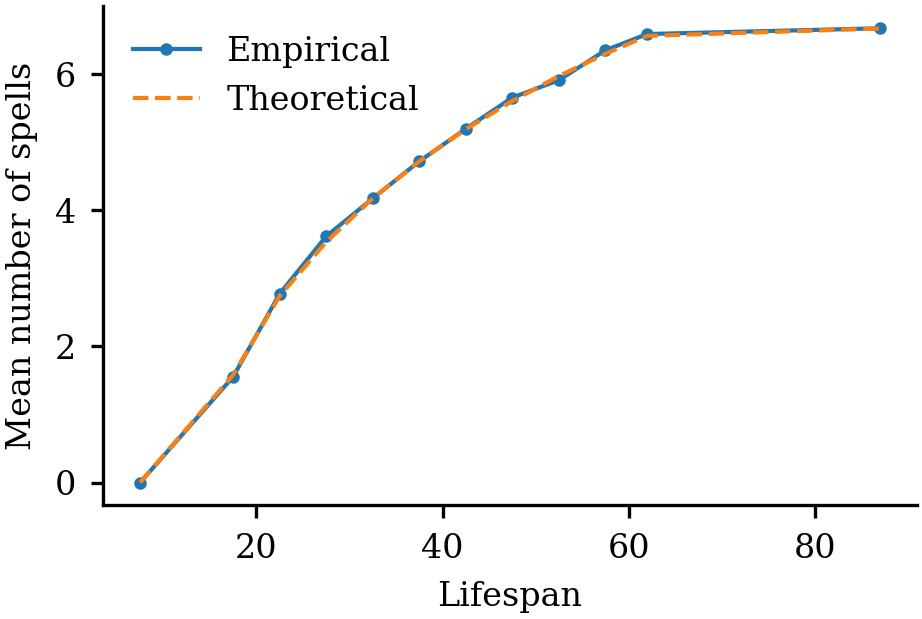

In [55]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

# -----------------------------
# Prepare individual dataset
# -----------------------------

# Filter Birth events
df_birth = df[df["event_name"] == "Birth"].copy()

# Extract lifespan per id
lifespan_df = df_birth[["id", "main_duration"]].rename(
    columns={"main_duration": "lifespan"}
)

# Filter work-related events
df_work = df[df["event_name"].str.startswith("Work_")]

# Count number of work spells per individual
work_counts = (
    df_work.groupby("id")
    .size()
    .reset_index(name="number_of_spells")
)

# Merge lifespan and number of spells
df_individual = lifespan_df.merge(
    work_counts,
    on="id",
    how="left"
)

# Replace missing spells with 0
df_individual["number_of_spells"] = (
    df_individual["number_of_spells"]
    .fillna(0)
    .astype(int)
)

# -----------------------------
# Custom lifespan bins
# -----------------------------

bins = [0, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 64, 110]

# Optional: readable labels
labels = (
    ["[0,15]"] +
    [f"]{a},{b}]" for a, b in zip(bins[1:-1], bins[2:])]
)

df_individual["lifespan_bin"] = pd.cut(
    df_individual["lifespan"],
    bins=bins,
    labels=labels,
    right=True,          # (a, b]
    include_lowest=True  # [0,15]
)

# -----------------------------
# Empirical statistics
# -----------------------------

emp_stats = (
    df_individual
    .groupby("lifespan_bin")["number_of_spells"]
    .agg(["mean", "var", "count"])
    .reset_index()
)

# Compute bin centers manually (important since bins are irregular)
bin_centers = [(a + b) / 2 for a, b in zip(bins[:-1], bins[1:])]
emp_stats["bin_center"] = bin_centers

# -----------------------------
# Truncated Poisson model
# -----------------------------

MAX_K = 11

def truncated_poisson_moments(lmbda, max_k):
    k = np.arange(0, max_k + 1)

    pmf = poisson.pmf(k, lmbda)
    tail_prob = 1 - poisson.cdf(max_k, lmbda)

    truncated_pmf = pmf / (1 - tail_prob)

    mean = np.sum(k * truncated_pmf)
    second_moment = np.sum(k**2 * truncated_pmf)

    var = second_moment - mean**2

    return mean, var

# -----------------------------
# Theoretical values
# -----------------------------

theo_means = []
theo_vars = []

for L in emp_stats["bin_center"]:
    if L <= 15:
        theo_means.append(0)
        theo_vars.append(0)
    else:
        lmbda = np.sqrt(min(L, 64) - 15)
        m, v = truncated_poisson_moments(lmbda, MAX_K)
        theo_means.append(m)
        theo_vars.append(v)

emp_stats["theo_mean"] = theo_means
emp_stats["theo_var"] = theo_vars

# -----------------------------
# Plot
# -----------------------------

plt.figure()

plt.plot(
    emp_stats["bin_center"],
    emp_stats["mean"],
    marker="o",
    label="Empirical",
    markersize=2
)

plt.plot(
    emp_stats["bin_center"],
    emp_stats["theo_mean"],
    linestyle="--",
    label="Theoretical"
)

plt.xlabel("Lifespan")
plt.ylabel("Mean number of spells")
plt.legend()

plt.show()

In [56]:
emp_stats[["lifespan_bin", "mean", "theo_mean"]]

,lifespan_bin,mean,theo_mean
0,"[0,15]",0.000000,0.000000
1,"]15,20]",1.553241,1.581138
2,"]20,25]",2.772404,2.738324
3,"]25,30]",3.615463,3.532748
4,"]30,35]",4.170970,4.172313
5,"]35,40]",4.715493,4.715006
6,"]40,45]",5.193579,5.186398
7,"]45,50]",5.651498,5.600768
8,"]50,55]",5.906961,5.967536
9,"]55,60]",6.345625,6.293685


# Mapped in 2010

age

In [57]:
def mapping_to_time_dep(df_time_indep, t):
    
    # Keep only Birth events
    df_birth = df_time_indep[
        df_time_indep["event_name"] == "Birth"
    ].copy()
    
    # Rename for clarity
    df_birth = df_birth[["id", "main_start_date", "main_duration"]]
    df_birth = df_birth.rename(columns={
        "main_start_date": "birth_date",
        "main_duration": "lifespan"
    })
    
    # Compute death time
    df_birth["death_time"] = (
        df_birth["birth_date"] + df_birth["lifespan"]
    )
    
    # Initialize status
    df_birth["alive_status"] = "Dead"
    
    # Not born
    df_birth.loc[
        df_birth["birth_date"] > t,
        "alive_status"
    ] = "Not born"
    
    # Alive
    df_birth.loc[
        (df_birth["birth_date"] <= t) &
        (t < df_birth["death_time"]),
        "alive_status"
    ] = "Alive"
    
    # Compute age only if alive
    df_birth["age"] = np.nan
    
    alive_mask = df_birth["alive_status"] == "Alive"
    df_birth.loc[alive_mask, "age"] = (
        t - df_birth.loc[alive_mask, "birth_date"]
    )
    
    # Final dataset
    df_time_dep = df_birth[["id", "alive_status", "age"]].copy()
    
    return df_time_dep

In [58]:
df_2010 = mapping_to_time_dep(df, 2010)

In [59]:
from scipy.integrate import quad

def age_density(age, t, lam=85, k=3,
                a=1900, b=2050,
                L_max=110):
    """
    Density of age at time t conditional on being alive at t.

    Parameters
    ----------
    age : float
        Observed age.
    t : float
        Time at which age is evaluated.
    lam : float
        Weibull scale parameter.
    k : float
        Weibull shape parameter.
    a : float
        Lower bound of uniform DOB.
    b : float
        Upper bound of uniform DOB.
    L_max : float
        Upper truncation of lifespan.

    Returns
    -------
    float
        Density value f_{A_t | alive}(age).
    """

    # Support bounds
    alpha = max(0.0, t - b)
    beta = min(t - a, L_max)

    # If no alive population
    if alpha >= beta:
        return 0.0

    # Outside support
    if age < alpha or age > beta:
        return 0.0

    # Precompute truncation constant
    c = np.exp(-(L_max / lam)**k)

    # Survival function of truncated Weibull
    def survival(x):
        return (
            np.exp(-(x / lam)**k) - c
        ) / (1 - c)

    # Normalization constant
    denom, _ = quad(survival, alpha, beta)

    if denom <= 0:
        return 0.0

    return survival(age) / denom

In [60]:
x_grid = np.linspace(0, 110, 300)
density_values = []
for i in range (len(x_grid)):
    density_values.append(age_density(x_grid[i], 2010))

In [61]:
setup_ieee_style(column="one", fontsize=8, use_tex=False)
fig, ax = plt.subplots()
hist_with_density(ax, data = np.array(df_2010[df_2010["alive_status"] == "Alive"]["age"]), bins=30, x_grid = x_grid, density_values=density_values)
ieee_axes(ax, xbins=5, ybins=5)

ax.set_xlabel("Age in 2010")
ax.set_ylabel("Probability density")
ax.legend()
fig.savefig("age_2010.pdf")
plt.close(fig)

Car availability and driving license

In [62]:
def map_license_status_by_residence(df_time_indep):
    """
    Function to determine if an individual has obtained a driving license before the start of each residence spell.
    The status is assigned as 1 if the individual has the license at the start of the residence spell, else 0.
    For non-Home spells, the status will be NA.
    """
    
    # Prepare an empty list to store results
    results = []
    
    # Iterate through each individual
    for ind_id, df_ind in df_time_indep.groupby("id"):
        
        # Extract residence spells (Home events) and other events
        residence_spells = df_ind[df_ind["event_name"].str.contains("Home")].copy()
        
        # Extract DL event details (assume one DL event per individual)
        dl_events = df_ind[df_ind["event_name"] == "DL"]
        
        if len(dl_events) == 0:
            continue
        
        # Get DL start and end dates
        dl_start_date = dl_events["main_start_date"].iloc[0]
        dl_end_date = dl_start_date + dl_events["main_duration"].iloc[0]
        
        # Iterate over all rows (including non-Home events)
        for _, row in df_ind.iterrows():
            # For "Home" events, check if DL is obtained before the start of the spell
            if "Home" in row["event_name"]:
                home_start_date = row["main_start_date"]
                home_end_date = home_start_date + row["main_duration"]
                
                # Check if the individual has obtained the license before the start of the residence spell
                if dl_start_date <= home_start_date:
                    license_status = 1  # License obtained before the start of the spell
                else:
                    license_status = 0  # License not obtained before the start of the spell
            else:
                # For non-Home events, set license status to NA
                license_status = None

            # Add the license status as a new column
            row["license_status"] = license_status
            results.append(row)
    
    # Return the updated dataframe with the new "license_status" column
    return pd.DataFrame(results)

In [63]:
df_ = map_license_status_by_residence(df)

In [64]:
def mapping_residence_status(df_ind, age):
    """
    Returns PlaceResidence at given age for one individual.
    """
    
    if pd.isna(age):
        return None
    
    # Select residence spells
    home_rows = df_ind[
        df_ind["event_name"].str.contains("Home")
    ].copy()
    
    if len(home_rows) == 0:
        return None
    
    # Extract spell order
    # Home0 has no underscore
    def extract_home_id(name):
        if name == "Home0":
            return 0
        else:
            return int(name.split("_")[1])
    
    home_rows["spell_id"] = home_rows["event_name"].apply(extract_home_id)
    home_rows = home_rows.sort_values("spell_id")
    
    remaining_time = age
    
    for _, row in home_rows.iterrows():
        dur = row["main_duration"]
        
        if remaining_time < dur:
            return row["PlaceResidence"], row["Car_availability"], row["license_status"]
        
        remaining_time -= dur
    
    # If age exceeds total residence duration (rare but possible)
    return home_rows.iloc[-1]["PlaceResidence"], home_rows.iloc[-1]["Car_availability"], home_rows.iloc[-1]["license_status"]

In [65]:
def mapping_full_residence_snapshot(df_time_indep, t):
    
    snapshot = mapping_to_time_dep(df_time_indep, t)
    # expected columns: id, alive, age
    
    results = []
    
    for ind_id, df_ind in df_time_indep.groupby("id"):
        
        row = snapshot[snapshot["id"] == ind_id]
        if len(row) == 0:
            continue
        
        alive = row["alive_status"].iloc[0]
        age   = row["age"].iloc[0]
        
        if alive != "Alive":
            results.append({
                "id": ind_id,
                "alive_status": 0,
                "age": np.nan,
                "PlaceResidence": None,
                "Car_availability": None,
                "License_status":None
            })
            continue
        
        residence, car_av, license = mapping_residence_status(df_ind, age)
        
        results.append({
            "id": ind_id,
            "alive_status": 1,
            "age": age,
            "PlaceResidence": residence,
            "Car_availability": car_av,
            "License_status": license
        })
    
    return pd.DataFrame(results)

In [66]:
df_everything = mapping_full_residence_snapshot(df_, 2010)

In [67]:
# Define the start, end, and number of bins
start_age = 0
end_age = 110
num_bins = 35

# Create age bins automatically
bins = np.linspace(start_age, end_age, num_bins + 1)
labels = [f'{bins[i]}-{bins[i+1]}' for i in range(num_bins)]

# Bin the ages for both empirical and theoretical calculations
df_everything['age_group'] = pd.cut(df_everything['age'], bins=bins, labels=labels, right=False)

# Calculate the percentage of car availability in each age group (Empirical)
empirical = df_everything.groupby('age_group')['Car_availability'].mean() * 100

# Calculate the percentage of driving license status in each age group (Theoretical)
theoretical = df_everything.groupby('age_group')['License_status'].mean() * 100 * 0.76

# Reindex both series to ensure all bins are present, even if empty, and fill missing values with NaN
empirical = empirical.reindex(labels, fill_value=np.nan)
theoretical = theoretical.reindex(labels, fill_value=np.nan)

# Now both empirical and theoretical will have the same length, and empty bins will be filled with NaN
print(len(empirical))  # Should match the length of 'labels'
print(len(theoretical))  # Should match the length of 'labels'
print(len(bins))

35
35
36


C:\Users\baud\AppData\Local\Temp\ipykernel_2208\1553072316.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  empirical = df_everything.groupby('age_group')['Car_availability'].mean() * 100
C:\Users\baud\AppData\Local\Temp\ipykernel_2208\1553072316.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  theoretical = df_everything.groupby('age_group')['License_status'].mean() * 100 * 0.76


In [68]:
setup_ieee_style(column="one", fontsize=8, use_tex=False)
fig, ax = plt.subplots()
hist_with_theoretical_line(ax, empirical_data = empirical, theoretical_data = theoretical, bins = bins)
ieee_axes(ax, xbins=5, ybins=5)

ax.set_xlabel("Age")
ax.set_ylabel("Car availability")
ax.legend()
fig.savefig("car_av_2010.pdf")
plt.close(fig)

Canton of residence

In [69]:
def mapping_residence_status(df_ind, age):
    """
    Returns PlaceResidence at given age for one individual.
    """
    
    if pd.isna(age):
        return None
    
    # Select residence spells
    home_rows = df_ind[
        df_ind["event_name"].str.contains("Home")
    ].copy()
    
    if len(home_rows) == 0:
        return None
    
    # Extract spell order
    # Home0 has no underscore
    def extract_home_id(name):
        if name == "Home0":
            return 0
        else:
            return int(name.split("_")[1])
    
    home_rows["spell_id"] = home_rows["event_name"].apply(extract_home_id)
    home_rows = home_rows.sort_values("spell_id")
    
    remaining_time = age
    
    for _, row in home_rows.iterrows():
        dur = row["main_duration"]
        
        if remaining_time < dur:
            return row["PlaceResidence"], row["Car_availability"]
        
        remaining_time -= dur
    
    # If age exceeds total residence duration (rare but possible)
    return home_rows.iloc[-1]["PlaceResidence"], home_rows.iloc[-1]["Car_availability"]

In [70]:
def mapping_full_residence_snapshot(df_time_indep, t):
    
    snapshot = mapping_to_time_dep(df_time_indep, t)
    # expected columns: id, alive, age
    
    results = []
    
    for ind_id, df_ind in df_time_indep.groupby("id"):
        
        row = snapshot[snapshot["id"] == ind_id]
        if len(row) == 0:
            continue
        
        alive = row["alive_status"].iloc[0]
        age   = row["age"].iloc[0]
        
        if alive != "Alive":
            results.append({
                "id": ind_id,
                "alive_status": 0,
                "age": np.nan,
                "PlaceResidence": None,
                "Car_availability": None
            })
            continue
        
        residence, car_av = mapping_residence_status(df_ind, age)
        
        results.append({
            "id": ind_id,
            "alive_status": 1,
            "age": age,
            "PlaceResidence": residence,
            "Car_availability": car_av
        })
    
    return pd.DataFrame(results)

In [71]:
df_place_res = mapping_full_residence_snapshot(df, 2010)

In [72]:
# Canton name → official abbreviation mapping
canton_abbrev = {
    "Zurich": "ZH",
    "Bern": "BE",
    "Vaud": "VD",
    "Aargau": "AG",
    "St Gallen": "SG",
    "Geneva": "GE",
    "Lucerne": "LU",
    "Valais": "VS",
    "Ticino": "TI",
    "Fribourg": "FR",
    "Basel Landschaft": "BL",
    "Thurgau": "TG",
    "Solothurn": "SO",
    "Graubunden": "GR",
    "Basel Stadt": "BS",
    "Neuchatel": "NE",
    "Schwyz": "SZ",
    "Zug": "ZG",
    "Schaffhausen": "SH",
    "Jura": "JU",
    "Appenzell Ausserrhoden": "AR",
    "Nidwalden": "NW",
    "Glarus": "GL",
    "Obwalden": "OW",
    "Uri": "UR",
    "Appenzell Innerrhoden": "AI",
}

df_place_res["PlaceResidence"] = (
    df_place_res["PlaceResidence"]
    .str.replace("_", " ", regex=False)
    .map(canton_abbrev)
)

In [73]:
def hist_categorical_with_reference(
    ax: plt.Axes,
    x,
    *,
    df_reference=None,
    category_col=None,
    value_col=None,
    normalize=True,
    rotation=90,
    tick_fontsize=6,
    alpha=0.35,
):

    x = np.asarray(x)
    x = x[x != None]

    categories, counts = np.unique(x, return_counts=True)

    order = np.argsort(-counts)
    categories = categories[order]
    counts = counts[order]

    if normalize:
        counts = counts / counts.sum()
        ax.set_ylabel("Proportion")
    else:
        ax.set_ylabel("Count")

    positions = np.arange(len(categories))

    # READ COLORS *AFTER* STYLE IS SET
    color_cycle = mpl.rcParams["axes.prop_cycle"].by_key()["color"]
    blue = color_cycle[0]
    orange = color_cycle[1]

    # Synthetic bars
    ax.bar(
        positions,
        counts,
        edgecolor="black",
        linewidth=0.8,
        alpha=alpha,
        color=blue,
        label="Sample",
    )

    # Reference overlay
    if df_reference is not None:
        ref_map = dict(
            zip(df_reference[category_col], df_reference[value_col])
        )
        ref_values = np.array([ref_map.get(cat, 0) for cat in categories])

        ax.scatter(
            positions,
            ref_values,
            marker="o",
            s=10,
            color=orange,        # ← this will now be orange
            zorder=3,
            label="True density",
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(
        categories,
        rotation=rotation,
        ha="right",
        fontsize=tick_fontsize,
    )

    ax.legend()

    return categories, counts

In [74]:
canton_proportions = {
    "ZH": 0.1791,
    "BE": 0.1187,
    "VD": 0.0944,
    "AG": 0.0811,
    "SG": 0.0597,
    "GE": 0.0585,
    "LU": 0.0483,
    "VS": 0.0408,
    "TI": 0.0399,
    "FR": 0.0381,
    "BL": 0.0333,
    "TG": 0.0329,
    "SO": 0.0320,
    "GR": 0.0229,
    "BS": 0.0223,
    "NE": 0.0199,
    "SZ": 0.0187,
    "ZG": 0.0148,
    "SH": 0.0097,
    "JU": 0.0083,
    "AR": 0.0063,
    "NW": 0.0050,
    "GL": 0.0047,
    "OW": 0.0044,
    "UR": 0.0042,
    "AI": 0.0019,
}

df_cantons = pd.DataFrame(
    canton_proportions.items(),
    columns=["PlaceResidence", "Proportion"]
)

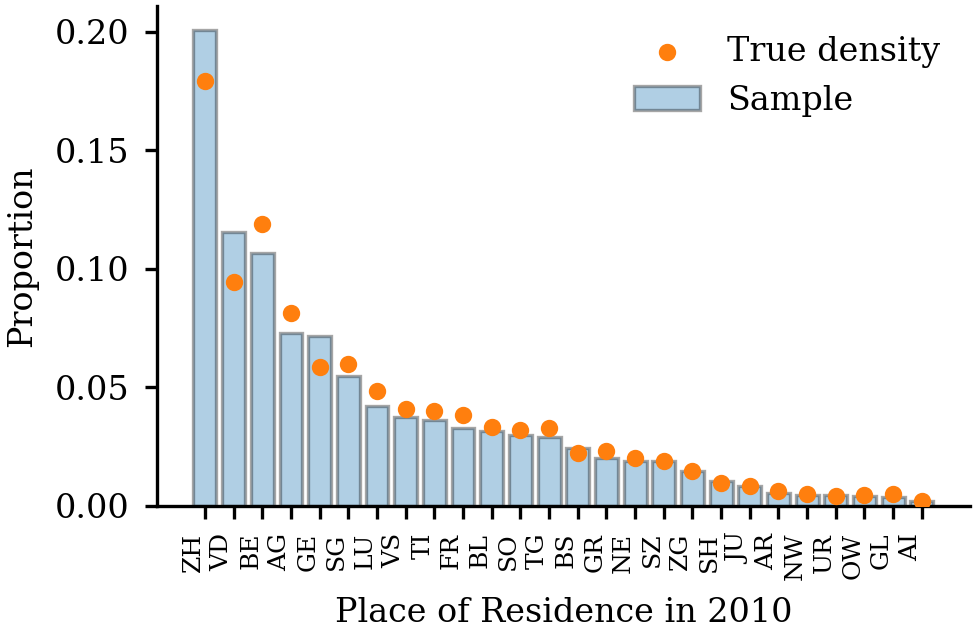

In [75]:
setup_ieee_style(column="one")

fig, ax = plt.subplots()

hist_categorical_with_reference(
    ax,
    df_place_res[df_place_res["alive_status"] == 1]["PlaceResidence"],
    df_reference=df_cantons,
    category_col="PlaceResidence",
    value_col="Proportion",
)

ax.set_xlabel("Place of Residence in 2010")

fig.savefig("cantons.pdf")

income in 2010

In [76]:
def active_events_at_time(df: pd.DataFrame, t: float) -> pd.DataFrame:
    """maps active event of each dimension at time t and keeps attributes"""
    df = df.copy()

    # --- compute end dates
    main_end = df["main_start_date"] + df["main_duration"]
    gap_end  = df["gap_start_date"] + df["gap_duration"]

    # --- activity indicators
    df["main"] = ((df["main_start_date"] <= t) & (t < main_end)).astype(int)
    df["gap"]  = ((df["gap_start_date"] <= t) & (t < gap_end)).astype(int)

    # --- keep only active rows
    df_active = df[(df["main"] == 1) | (df["gap"] == 1)].copy()

    # --- resolve conflicts: one event per (id, dim_name)
    df_active["priority"] = df_active["main"]  # main > gap

    df_active = (
        df_active
        .sort_values(["id", "dim_name", "priority"], ascending=[True, True, False])
        .drop_duplicates(subset=["id", "dim_name"], keep="first")
        .drop(columns="priority")
    )

    # --- IMPORTANT: keep ALL columns
    # Just reorder so main/gap are visible
    cols_front = ["id", "dim_name", "event_name", "main", "gap"]
    other_cols = [c for c in df_active.columns if c not in cols_front]

    result = df_active[cols_front + other_cols].reset_index(drop=True)

    return result


In [102]:
def work_features_at_time(df: pd.DataFrame, t: float) -> pd.DataFrame:
    results = []

    # --- get active events at time t
    df_active = active_events_at_time(df, t)

    # --- keep only employment dimension
    df_work_active = df_active[df_active["dim_name"] == "Employment"]

    for ind_id, row in df_work_active.groupby("id"):

        row = row.iloc[0]

        current_spell = row["event_name"]
        is_main = row["main"]
        is_gap  = row["gap"]
        log_income = row["LogIncome"]

        # --- start time of current spell
        if is_main == 1:
            t_start = row["main_start_date"]
        else:
            t_start = row["gap_start_date"]

        # --- full history
        g = df[df["id"] == ind_id].copy()

        # =========================
        # 1) EDUCATION BEFORE WORK SPELL
        # =========================
        educ = g[g["event_name"].isin(EDUC_EVENTS)].copy()
        educ["end_date"] = educ["main_start_date"] + educ["main_duration"]

        educ_completed = educ[educ["end_date"] <= t_start]

        educ_years = educ_completed["main_duration"].sum()

        # --- last achieved education level
        if not educ_completed.empty:
            last_educ = educ_completed.loc[educ_completed["end_date"].idxmax()]
            educ_level = last_educ["event_name"]
        else:
            educ_level = None

        # =========================
        # 2) WORK EXPERIENCE BEFORE CURRENT SPELL
        # =========================
        work = g[g["dim_name"] == "Employment"].copy()
        work["end_date"] = work["main_start_date"] + work["main_duration"]

        work_completed = work[
            (work["main_duration"] > 0) &
            (work["end_date"] <= t_start) &
            (work["event_name"] != "NoWork")
        ]

        work_experience = work_completed["main_duration"].sum()

        results.append({
            "id": ind_id,
            "current_work_spell": current_spell,
            "main": int(is_main),
            "gap": int(is_gap),
            "educ_years_before_work_spell": educ_years,
            "educ_level": educ_level,  # <-- added
            "work_experience_before_work_spell": work_experience,
            "LogIncome": log_income
        })

    return pd.DataFrame(results)

In [103]:
df_work_status = work_features_at_time(df, 2010)
df_work_status["expected_income"] = 7.8 + 0.025*df_work_status["work_experience_before_work_spell"] -0.0004*df_work_status["work_experience_before_work_spell"]**2 + 0.1*df_work_status["educ_years_before_work_spell"]

In [156]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def hist_with_expected_curve(
    ax: plt.Axes,
    log_income: np.ndarray,
    expected_income: np.ndarray,
    *,
    bins: int = 30,
    range=None,
    hist_alpha: float = 0.35,
    linewidth: float = 2.5,
    label_hist: str = "Sample",
    label_curve: str = "Approximate True Density",
):
    """
    Histogram (density) of log_income + smooth KDE curve of expected_income.
    """

    # --- clean data ---
    log_income = np.asarray(log_income)
    expected_income = np.asarray(expected_income)

    log_income = log_income[np.isfinite(log_income)]
    expected_income = expected_income[np.isfinite(expected_income)]

    # --- histogram ---
    counts, bin_edges, patches = ax.hist(
        log_income,
        bins=bins,
        range=range,
        density=True,
        alpha=hist_alpha,
        edgecolor="black",
        linewidth=0.8,
        label=label_hist,
    )

    # --- define plotting support (important!) ---
    xmin = min(log_income.min(), expected_income.min())
    xmax = max(log_income.max(), expected_income.max())
    x_grid = np.linspace(xmin, xmax, 300)

    # --- KDE for expected income ---
    kde = gaussian_kde(expected_income)
    y_kde = kde(x_grid)

    # --- plot curve ---
    ax.plot(
        x_grid,
        y_kde,
        linewidth=linewidth,
        label=label_curve,
    )

    # --- cosmetics ---
    ax.set_ylabel("Density")
    ax.set_xlabel("Log income")
    ax.legend()

    return (counts, bin_edges, patches), (x_grid, y_kde)

In [157]:
log_income = df_work_status[(df_work_status['main']==1)&(df_work_status["current_work_spell"]!="NoWork")]["LogIncome"]
theo_income = df_work_status[(df_work_status['main']==1)&(df_work_status["current_work_spell"]!="NoWork")]["expected_income"] + np.random.normal(0, 0.3, len(log_income))

In [161]:
bins = 30
setup_ieee_style(column="one", fontsize=8, use_tex=False)
fig, ax = plt.subplots()
hist_with_expected_curve(ax, log_income = log_income, expected_income=theo_income, bins = bins)
ieee_axes(ax, xbins=5, ybins=5)

ax.set_xlabel("Log Income in 2010")
ax.set_ylabel("Probability density")
ax.legend(loc="upper left")
fig.savefig("log_income_2010.pdf")
plt.close(fig)